# day-13-semantic-search — worked solutions & answer key

Solutions to the exercises in [`../lesson.ipynb`](../lesson.ipynb), plus the self-check answer key. **Try each exercise yourself first** — the value is in the attempt, not the answer.

In [12]:
# ---- Solution 1 ----
Ur, Sr, _ = np.linalg.svd(C.astype(float))
raw_vecs = Ur[:, :K] * Sr[:K]
def wv_raw(w): return raw_vecs[idx[w]] if w in idx else np.zeros(K)
def embed_raw(s):
    vs = [wv_raw(w) for w in tokens(s) if w in idx]
    return np.mean(vs, 0) if vs else np.zeros(K)
Draw = np.array([embed_raw(d) for d in DOCS]); Draw /= (np.linalg.norm(Draw,axis=1,keepdims=True)+1e-9)
h = 0
for q, gold in QUERIES:
    qq = embed_raw(q); qq /= (np.linalg.norm(qq)+1e-9)
    h += int(np.argmax(Draw @ qq) == gold)
print(f"S1: raw-count SVD accuracy {h}/{len(QUERIES)} vs PPMI SVD {hits}/{len(QUERIES)} (from segment 2).")
print("    PPMI down-weights the 'everything co-occurs with common words' signal so the top")
print("    singular vectors capture meaning rather than raw frequency. On a real corpus the")
print("    gap is large; on ~30 sentences both are noisy.")

S1: raw-count SVD accuracy 2/5 vs PPMI SVD 2/5 (from segment 2).
    PPMI down-weights the 'everything co-occurs with common words' signal so the top
    singular vectors capture meaning rather than raw frequency. On a real corpus the
    gap is large; on ~30 sentences both are noisy.


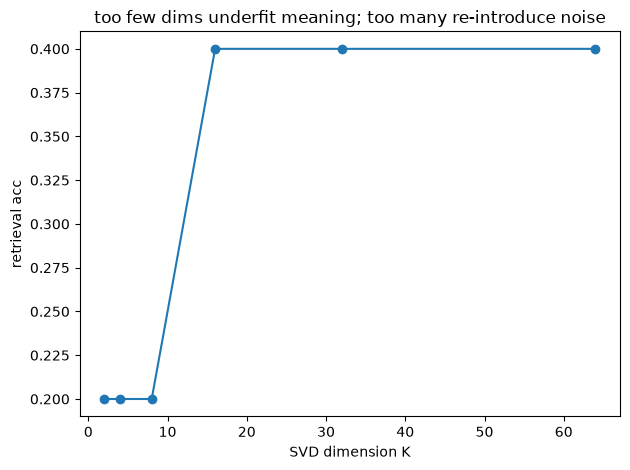

{2: 0.2, 4: 0.2, 8: 0.2, 16: 0.4, 32: 0.4, 64: 0.4}


In [13]:
# ---- Solution 2 ----
def acc_for_K(k):
    wvk = U[:, :k] * S[:k]
    def emb(s):
        vs = [wvk[idx[w]] for w in tokens(s) if w in idx]
        return np.mean(vs,0) if vs else np.zeros(k)
    Dk = np.array([emb(d) for d in DOCS]); Dk /= (np.linalg.norm(Dk,axis=1,keepdims=True)+1e-9)
    h = 0
    for q, gold in QUERIES:
        qq = emb(q); qq /= (np.linalg.norm(qq)+1e-9); h += int(np.argmax(Dk@qq)==gold)
    return h/len(QUERIES)
Ks = [2,4,8,16,32,64]
accs = [acc_for_K(k) for k in Ks]
plt.plot(Ks, accs, marker="o"); plt.xlabel("SVD dimension K"); plt.ylabel("retrieval acc")
plt.title("too few dims underfit meaning; too many re-introduce noise"); plt.tight_layout(); plt.show()
print(dict(zip(Ks, accs)))

In [14]:
# ---- Solution 5 ----
q = "how do I request reimbursement"
in_vocab = [w for w in tokens(q) if w in idx]
print("SVD sees only these query words:", in_vocab, "-> 'reimbursement' is dropped")
print("SVD top doc:", semantic_search(q)[0])
print("MiniLM top doc:", real_search(q)[0], "->", DOCS[real_search(q)[0][0]])
print("\nS5: subword tokenisation ('re', '##im', '##burse', '##ment') lets the real model place")
print("an unseen word near 'refund'. Bag-of-word-vectors can't represent OOV terms at all.")

SVD sees only these query words: ['how', 'do', 'i'] -> 'reimbursement' is dropped
SVD top doc: (0, 0.16708155865092542)
MiniLM top doc: (0, 0.4027354121208191) -> Refunds are processed within 5 business days to the original payment method.

S5: subword tokenisation ('re', '##im', '##burse', '##ment') lets the real model place
an unseen word near 'refund'. Bag-of-word-vectors can't represent OOV terms at all.


In [15]:
# ---- Solution 6 ----
# fresh queries (not stored): jitter base embeddings with independent noise
Qbig = np.repeat(base, 25, axis=0) + 0.035 * rng.standard_normal((len(DOCS)*25, base.shape[1]))
Qbig /= np.linalg.norm(Qbig, axis=1, keepdims=True)

def lsh_recall(n_planes, n_tables):
    L = LSH(big, n_planes=n_planes, n_tables=n_tables)
    hit, cand = 0, []
    for q in Qbig:
        c = L.candidates(q); cand.append(len(c))       # no full-scan fallback here
        exact = int(np.argmax(big @ q))
        hit += exact in c                              # was the true NN even a candidate?
    return hit/len(Qbig), np.mean(cand)

print(f"{'planes':>7} {'tables':>7} {'recall@1':>9} {'avg cands':>10}")
for npl, nt in [(8,1), (8,4), (8,10), (8,20), (12,20), (16,20)]:
    r, c = lsh_recall(npl, nt)
    print(f"{npl:>7} {nt:>7} {r:>9.2f} {c:>10.0f} / {len(big)}")
print("S6: more planes -> smaller buckets (faster, lower recall); more tables -> more buckets")
print("    probed -> recall back up at higher cost. That two-knob tradeoff is the core of ANN.")

 planes  tables  recall@1  avg cands


      8       1      0.09         21 / 2000
      8       4      0.34        113 / 2000


      8      10      0.77        246 / 2000


      8      20      0.92        422 / 2000
     12      20      0.55        119 / 2000


     16      20      0.23         38 / 2000
S6: more planes -> smaller buckets (faster, lower recall); more tables -> more buckets
    probed -> recall back up at higher cost. That two-knob tradeoff is the core of ANN.


### Solutions 3 & 4 (sketch)

**S3:** after `DOCS[3] = " ".join(tokens(DOCS[3]) * 10)`, rebuild an *un-normalised* doc matrix
and rank by raw `D @ q`. `DOCS[3]`'s vector norm is ~10× bigger so it floats to the top of
almost every query. Switch to cosine (normalise rows) and it drops back to its semantic rank.
This is why you normalise.

**S4:** `blended = w * minmax(bm25_scores) + (1-w) * minmax(sem_scores)`; loop `w` in
`np.linspace(0,1,11)`, count `TESTS` hits. Usually a broad plateau around `w ≈ 0.3–0.6` beats
either pure method — the exact value is dataset-specific, which is why rank-fusion (RRF, no
weight to tune) is popular.

### Answer key
1. Distinct words are orthogonal one-hot dimensions, so their similarity is exactly 0 — the
   representation encodes no relationship between different words.
2. "A word's meaning is characterised by the contexts it appears in." Build a word×context
   co-occurrence matrix over a corpus; words with similar meaning have similar rows; SVD
   compresses those rows to dense vectors preserving the similarity structure.
3. They give the **same ranking**: dot = cosine (norms are 1), and `‖a-b‖² = 2 - 2(a·b)` is
   monotonically decreasing in the dot product.
4. Because then a single inner-product matmul equals cosine similarity — fastest to compute,
   no per-query norm, and the metric matches how text embeddings encode meaning (direction).
5. Exact/rare terms: product codes, proper names, error strings, code identifiers, acronyms —
   anything where the literal token matters and paraphrase doesn't.
6. It combines the **rank positions** each retriever assigns to a document
   (`Σ 1/(c + rank)`), not their raw scores — so it needs no score calibration between a BM25
   score and a cosine similarity, which live on different scales.
7. Recall (it may miss the true nearest neighbour) in exchange for sublinear query time /
   lower memory — essential past ~10⁵–10⁶ vectors.